# Data Extraction

In [1]:
import requests
from bs4 import BeautifulSoup
import argparse
from urllib.parse import urlparse
import subprocess
import os
import tempfile
import json
import sys
import pickle
import pandas as pd
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [2]:
df = pd.DataFrame()
with open("../results/results_full_part2.pkl", 'rb') as f:
    df = pickle.load(f)

In [4]:
df.sample(5)

,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
3226,https://archive.softwareheritage.org/browse/revision/dbf6f98b9ac2b0723f9b99736a4adb08a9b4aaa2/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/62a2f014977e978fb20fd494cfd498ca66e4b9c2/directory/?branch=refs/heads/main&path=LICENSE,bsd-new,bsd-new
1470,https://archive.softwareheritage.org/browse/revision/e75777fd59901613fbf27acb0979f37a5932b389/?path=tools/src/main/java/org/infinispan/tools/licenses/LicenseMerger.java,https://archive.softwareheritage.org/browse/snapshot/a02e67389c680510ecd70fd20296d7d188239844/directory/?branch=refs/heads/main&path=tools/src/main/java/org/infinispan/tools/licenses/LicenseMerger.java,None,None
2005,https://archive.softwareheritage.org/browse/revision/9c4129677f3066b95c340801757bbd13d05f602d/?path=examples/data-objects/multiview/interface/LICENSE,https://archive.softwareheritage.org/browse/snapshot/dfe577573e54219a9b87a6371a257e6dc8f6a7f8/directory/?branch=refs/heads/main&path=examples/data-objects/multiview/interface/LICENSE,mit,mit
2779,https://archive.softwareheritage.org/browse/revision/12ed05f49acce78438c4958a91b8c5c56b0526bd/?path=.licenses/npm/@actions/cache.dep.yml,https://archive.softwareheritage.org/browse/snapshot/7afeea61aa78e4f8e450d3ecbb1bd27d826a64de/directory/?branch=refs/heads/main&path=.licenses/npm/@actions/cache.dep.yml,mit,mit
1511,https://archive.softwareheritage.org/browse/revision/3b0d364e80798dd248b325759995090be8139b79/?path=actiontext/MIT-LICENSE,https://archive.softwareheritage.org/browse/snapshot/2d3bbf761ee7059270a117fd9578a7781aefa5f0/directory/?branch=refs/heads/main&path=actiontext/MIT-LICENSE,mit,mit


In [4]:
df_without_na = df.loc[~df['Rev-License-Scanned'].isna() & ~df['Snap-License-Scanned'].isna()]
print(f'Out of {len(df)} changed license detected, {len(df)-len(df_without_na)} didn\'t have both licenses scanned')

Out of 4147 changed license detected, 618 didn't have both licenses scanned


In [5]:
df_same = df_without_na.loc[df_without_na['Rev-License-Scanned'] == df_without_na['Snap-License-Scanned']]

In [6]:
df_same.head()

,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
0,https://archive.softwareheritage.org/browse/revision/b5f19db0568959b81d8dcb0402d35cd64e680d30/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/627839659fc4a3aac1c53f78cb3326d39715c804/directory/?branch=refs/heads/main&path=LICENSE,apache-2.0,apache-2.0
1,https://archive.softwareheritage.org/browse/revision/ce005be7fe4254065d06cf355df18189f2c510c5/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/4222b06c76d570b02fa89a348fd46e5ee790b48f/directory/?branch=refs/heads/main&path=LICENSE,mit,mit
2,https://archive.softwareheritage.org/browse/revision/1f24ac997775d7d82c37849c9ab740c5165806c8/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/03a50be8b03cb811c9c2a7c1d50ddf8e0226931a/directory/?branch=refs/heads/main&path=LICENSE,wtfpl-2.0,wtfpl-2.0
3,https://archive.softwareheritage.org/browse/revision/a4ff66fd728612f6e163c3cfa3f3ec468d224275/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/9256442171c260c256ba4677776791925df099c6/directory/?branch=refs/heads/main&path=LICENSE,agpl-3.0,agpl-3.0
5,https://archive.softwareheritage.org/browse/revision/b0fd94caeb73273231fc1d1aef979470019ece02/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/ccf805a02162d25c5525688fcdcb89963b573643/directory/?branch=refs/heads/main&path=LICENSE,mit,mit


In [5]:
df_diff = df_without_na.loc[df_without_na['Rev-License-Scanned'] != df_without_na['Snap-License-Scanned']]
print(f'{len(df_diff)} cases of license change detected')

555 cases of license change detected


In [6]:
df_diff.head()

,Rev-License-Path,Snap-License-Path,Rev-License-Scanned,Snap-License-Scanned
29,https://archive.softwareheritage.org/browse/revision/5fc3cdf857ab654f6a519f9c4d66ef60d397815e/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/07b3def11887046e9939f02fd7dd480a96741e7e/directory/?branch=refs/heads/main&path=LICENSE,mit,gpl-3.0
30,https://archive.softwareheritage.org/browse/revision/443e54adfc879787401617a763cd02b621b546a9/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/63ad5f4f196b35f2d22ed9d80186f30c2beea7cf/directory/?branch=refs/heads/main&path=LICENSE,mit,apache-2.0
34,https://archive.softwareheritage.org/browse/revision/116b11e6a17e89d54616d182bcd9f251ce66f543/?path=LICENSE.md,https://archive.softwareheritage.org/browse/snapshot/a9bb95449fba819448baece724dec6030925770f/directory/?branch=refs/heads/main&path=LICENSE.md,mit,bsd-new
35,https://archive.softwareheritage.org/browse/revision/8eea4b898dd582f0f8cb3571c919ee77ac56daac/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/89255770a633943c3d0aec49de1c0f30b1ab589f/directory/?branch=refs/heads/main&path=LICENSE,unlicense,isc
38,https://archive.softwareheritage.org/browse/revision/5dd8caca7d81161eb719f419c1d02230f11f5582/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/7f70ab812e956e590909946864c8871b3905f2bf/directory/?branch=refs/heads/main&path=LICENSE,apache-2.0,mit


In [7]:
df_changes = df_diff[['Rev-License-Scanned', 'Snap-License-Scanned']].drop_duplicates()
len(df_changes)

145

In [8]:
df_changes.sample(2)

,Rev-License-Scanned,Snap-License-Scanned
2419,isc,gpl-3.0
1763,lgpl-2.1,bsd-simplified


In [9]:
output_path = "../results/license_changes.xlsx"
df_changes.to_excel(output_path, index=False)
print(f"DataFrame exported successfully to {output_path}")

DataFrame exported successfully to ../results/license_changes.xlsx


# Type of Change

In [10]:
df_diff = df_diff.rename(columns={
    'Rev-License-Scanned': 'from_license',
    'Snap-License-Scanned': 'to_license'
})

In [11]:
license_changes_class = pd.read_excel("../results/license_changes_class_v2.xlsx")

In [12]:
df_classified = df_diff.merge(
    license_changes_class,
    on=['from_license', 'to_license'],
    how='left'
)
df_classified.sample(5)

,Rev-License-Path,Snap-License-Path,from_license,to_license,from_family,to_family,change_type
285,https://archive.softwareheritage.org/browse/revision/8fc10bd3decd30b63f45cb9926d555850cab0482/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/ba050c9f20e0a08fd37f9106929fc7fd12018bbc/directory/?branch=refs/heads/main&path=LICENSE,unlicense,isc,Public Domain,ISC,Change
51,https://archive.softwareheritage.org/browse/revision/8dd69e0e238d00f4e593bdbdc3e6dbcc236683dd/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/ca995bda04fbd2c8f4f7da67928158c2a684f22b/directory/?branch=refs/heads/main&path=LICENSE,mit,gpl-3.0,MIT,GPL,Change
299,https://archive.softwareheritage.org/browse/revision/d46ffdf61fd33507d7a1a9e195b54e5073ed3170/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/611e91370cb252b3ab9995854bf8fe0fc72f0666/directory/?branch=refs/heads/main&path=LICENSE,gpl-3.0,mit,GPL,MIT,Change
247,https://archive.softwareheritage.org/browse/revision/674fdbda95386609920ecfbcf46da737c1fa29f6/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/c3695389fd939e3690cf4d3b0ca44e3dd38d80c1/directory/?branch=refs/heads/main&path=LICENSE,gpl-3.0,mit,GPL,MIT,Change
286,https://archive.softwareheritage.org/browse/revision/ad9e41652851e12fe2768f6c1cb72eef74b68dcf/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/7a2403e6ab302c7ac4ded4eacb611074a3c57714/directory/?branch=refs/heads/main&path=LICENSE,unlicense,gpl-3.0,Public Domain,GPL,Change


In [13]:
output_path = "../results/type_change_results.xlsx"
df_classified.to_excel(output_path, index=False)
print(f"DataFrame exported successfully to {output_path}")

DataFrame exported successfully to ../results/type_change_results.xlsx


In [14]:
ds = pd.read_csv("../results/repos_modified_full.csv", delimiter=';')
ds.head()

,origin,revision,snapshot_without,path,Rev-License-Path,Snap-License-Path,amount_contrib,amount_author,amount_committer,amount_snap,amount_rel,amount_rev,freq_snap,freq_rev
0,https://github.com/cloudmesh/cloudmesh-google,swh:1:rev:b5f19db0568959b81d8dcb0402d35cd64e680d30,swh:1:snp:627839659fc4a3aac1c53f78cb3326d39715c804,./LICENSE,https://archive.softwareheritage.org/browse/revision/b5f19db0568959b81d8dcb0402d35cd64e680d30/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/627839659fc4a3aac1c53f78cb3326d39715c804/directory/?branch=refs/heads/main&path=LICENSE,9,8,8,3,0,43,"0,002117149","0,030345801"
1,https://github.com/benjcabalona1029/benjcabalona1029.github.io,swh:1:rev:ce005be7fe4254065d06cf355df18189f2c510c5,swh:1:snp:4222b06c76d570b02fa89a348fd46e5ee790b48f,./LICENSE,https://archive.softwareheritage.org/browse/revision/ce005be7fe4254065d06cf355df18189f2c510c5/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/4222b06c76d570b02fa89a348fd46e5ee790b48f/directory/?branch=refs/heads/main&path=LICENSE,6,5,3,3,0,62,"0,002056203","0,042494859"
2,https://github.com/physixcat/knr,swh:1:rev:1f24ac997775d7d82c37849c9ab740c5165806c8,swh:1:snp:03a50be8b03cb811c9c2a7c1d50ddf8e0226931a,./LICENSE,https://archive.softwareheritage.org/browse/revision/1f24ac997775d7d82c37849c9ab740c5165806c8/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/03a50be8b03cb811c9c2a7c1d50ddf8e0226931a/directory/?branch=refs/heads/main&path=LICENSE,1,1,1,3,0,5,"0,023255814","0,03875969"
3,https://gitlab.com/vojta_vogo/OttoHumanoidNG.git,swh:1:rev:a4ff66fd728612f6e163c3cfa3f3ec468d224275,swh:1:snp:9256442171c260c256ba4677776791925df099c6,./LICENSE,https://archive.softwareheritage.org/browse/revision/a4ff66fd728612f6e163c3cfa3f3ec468d224275/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/9256442171c260c256ba4677776791925df099c6/directory/?branch=refs/heads/main&path=LICENSE,1,1,1,3,0,5,"0,022556391","0,037593985"
4,https://github.com/jonkoops/keycloak,swh:1:rev:8a405ed83c5b6340af2d092e61db5f2b851e5591,swh:1:snp:236ac4c2de396f53e14bedd347bf26782ada169c,./distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,https://archive.softwareheritage.org/browse/revision/8a405ed83c5b6340af2d092e61db5f2b851e5591/?path=distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,https://archive.softwareheritage.org/browse/snapshot/236ac4c2de396f53e14bedd347bf26782ada169c/directory/?branch=refs/heads/main&path=distribution/galleon-feature-packs/saml-adapter-galleon-pack/src/main/resources/license/licenses.xml,1579,1574,306,42,1680,13807,"0,027962716","9,19241012"


In [15]:
df_classified_full = ds.merge(
    df_classified,
    on=['Rev-License-Path', 'Snap-License-Path'],
    how='left'
)

In [18]:
df_classified_full.head(1)

,origin,revision,snapshot_without,path,Rev-License-Path,Snap-License-Path,amount_contrib,amount_author,amount_committer,amount_snap,amount_rel,amount_rev,freq_snap,freq_rev,from_license,to_license,from_family,to_family,change_type
0,https://github.com/cloudmesh/cloudmesh-google,swh:1:rev:b5f19db0568959b81d8dcb0402d35cd64e680d30,swh:1:snp:627839659fc4a3aac1c53f78cb3326d39715c804,./LICENSE,https://archive.softwareheritage.org/browse/revision/b5f19db0568959b81d8dcb0402d35cd64e680d30/?path=LICENSE,https://archive.softwareheritage.org/browse/snapshot/627839659fc4a3aac1c53f78cb3326d39715c804/directory/?branch=refs/heads/main&path=LICENSE,9,8,8,3,0,43,"0,002117149","0,030345801",NaN,NaN,NaN,NaN,NaN


In [16]:
output_path = "../results/results_full_v2.xlsx"
df_classified_full.to_excel(output_path, index=False)
print(f"DataFrame exported successfully to {output_path}")

DataFrame exported successfully to ../results/results_full_v2.xlsx


In [22]:
df_with_change = df_classified_full.dropna(subset=['change_type'])
print(f'Out of {len(df_classified_full)} license alterations we\'re analyzing {len(df_with_change)} that are detected as changed')

Out of 4155 license alterations we're analyzing 555 that are detected as changed


Total license changes analyzed: 555


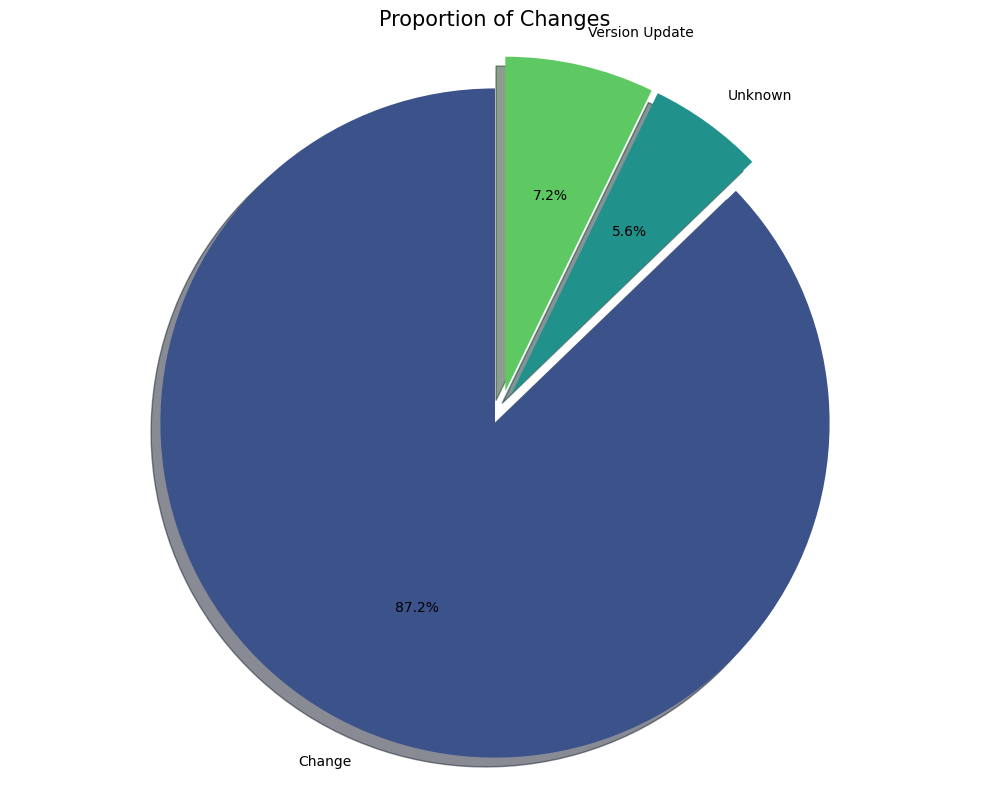

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Total license changes analyzed: {len(df_with_change)}")
precaution_counts = df_with_change['change_type'].value_counts().sort_index()

plt.figure(figsize=(10, 8))
plt.pie(precaution_counts, labels=precaution_counts.index, autopct='%1.1f%%', 
        startangle=90, shadow=True, explode=[0.05] * len(precaution_counts),
        colors=sns.color_palette('viridis', len(precaution_counts)))
plt.title('Proportion of Changes', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()